# Variational Quantum Classifier on Structured Data

Can a parameterised quantum circuit learn to classify structured data, and does it generalise to unseen combinations of features? This is a simplified version of the compositional generalisation problem.

I'm building this with Qiskit circuits and using numpy alongside to verify the gate-level mechanics.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit_aer import AerSimulator

np.random.seed(42)
simulator = AerSimulator()

## Generating structured synthetic data

Each sample has two discrete features (think: colour and shape, encoded as angles) and a binary label determined by a combinatorial rule. The key test later: can the circuit generalise to feature combinations it hasn't seen during training?

In [15]:
# feature A has 3 values, feature B has 3 values -> 9 combinations
# encoding features as rotation angles
feature_A_values = np.array([0.3, 1.2, 2.1])
feature_B_values = np.array([0.5, 1.8, 2.9])

# the rule: label = 1 when A and B are "compatible"
# this is a non-trivial XOR-like pattern — not linearly separable
compatibility = np.array([
    [1, 0, 1],  # A=0: compatible with B=0 and B=2
    [0, 1, 0],  # A=1: compatible with B=1 only
    [1, 0, 1],  # A=2: compatible with B=0 and B=2
])

data_points = []
labels = []
for i, a in enumerate(feature_A_values):
    for j, b in enumerate(feature_B_values):
        data_points.append([a, b])
        labels.append(compatibility[i, j])

data_points = np.array(data_points)
labels = np.array(labels)

print("All combinations:")
for k in range(len(data_points)):
    a_idx = np.argmin(np.abs(feature_A_values - data_points[k, 0]))
    b_idx = np.argmin(np.abs(feature_B_values - data_points[k, 1]))
    print(f"  A={a_idx}, B={b_idx} -> label={labels[k]}")

All combinations:
  A=0, B=0 -> label=1
  A=0, B=1 -> label=0
  A=0, B=2 -> label=1
  A=1, B=0 -> label=0
  A=1, B=1 -> label=1
  A=1, B=2 -> label=0
  A=2, B=0 -> label=1
  A=2, B=1 -> label=0
  A=2, B=2 -> label=1


Training on 6 combinations, testing on 3


C:\Users\ASUS\AppData\Local\Temp\ipykernel_26384\1474377952.py:16: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(data_points[k, 0], data_points[k, 1], marker=marker, c=color,


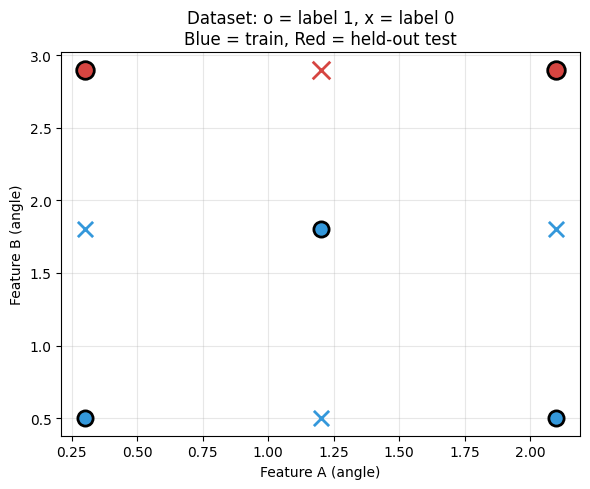

In [16]:
# train/test split: hold out specific combinations to test generalisation
# this is the critical test — can the circuit learn the RULE, not just memorise?
train_mask = np.array([True, True, False, True, True, False, True, True, False])
test_mask = ~train_mask

X_train, y_train = data_points[train_mask], labels[train_mask]
X_test, y_test = data_points[test_mask], labels[test_mask]

print(f"Training on {len(X_train)} combinations, testing on {len(X_test)}")

fig, ax = plt.subplots(figsize=(6, 5))
for k in range(len(data_points)):
    marker = 'o' if labels[k] == 1 else 'x'
    color = '#3498DB' if train_mask[k] else '#D64541'
    size = 120 if train_mask[k] else 160
    ax.scatter(data_points[k, 0], data_points[k, 1], marker=marker, c=color,
               s=size, edgecolors='black', linewidth=2, zorder=3)
ax.set_xlabel('Feature A (angle)')
ax.set_ylabel('Feature B (angle)')
ax.set_title('Dataset: o = label 1, x = label 0\nBlue = train, Red = held-out test')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Building the variational circuit in Qiskit

The circuit uses data re-uploading, the input features are encoded into every variational layer, not just at the start. This is important because a single encoding followed by parameterised rotations has limited expressivity. Re-uploading the data interleaved with trainable gates lets the circuit build up a more complex decision function, similar to how a deep classical network applies nonlinearities repeatedly.

Each layer consists of:
1. **Data encoding**: Ry rotations with angles that are linear functions of the features (trainable weights + biases)
2. **Variational rotations**: Ry + Rz on each qubit
3. **Entangling gate**: CNOT between qubits

Circuit: 2 qubits, 4 layers, 34 trainable parameters


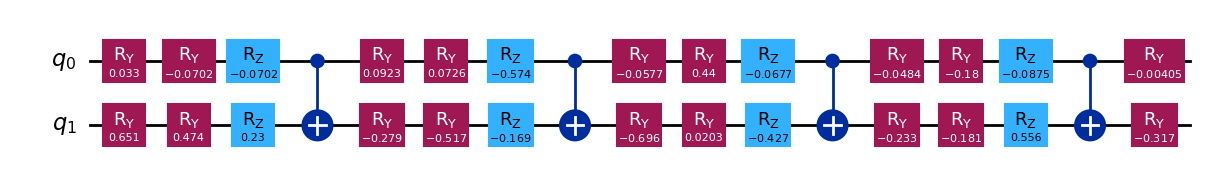

In [17]:
n_qubits = 2
n_layers = 4

# per layer: 2 encoding weights + 2 encoding biases + 2 Ry + 2 Rz = 8
# plus 2 final output rotations
params_per_layer = 8
n_params = n_layers * params_per_layer + 2  # +2 for final Ry rotations
print(f"Circuit: {n_qubits} qubits, {n_layers} layers, {n_params} trainable parameters")

def build_vqc(x, params):
    """
    Variational quantum classifier with data re-uploading.
    Features are encoded in every layer with trainable encoding weights.
    """
    qc = QuantumCircuit(n_qubits)
    
    for l in range(n_layers):
        offset = l * params_per_layer
        
        # data encoding with trainable weights: Ry(w * x + b)
        # this lets the circuit learn HOW to encode the features
        qc.ry(params[offset + 0] * x[0] + params[offset + 1], 0)
        qc.ry(params[offset + 2] * x[1] + params[offset + 3], 1)
        
        # variational rotations
        qc.ry(params[offset + 4], 0)
        qc.rz(params[offset + 5], 0)
        qc.ry(params[offset + 6], 1)
        qc.rz(params[offset + 7], 1)
        
        # entanglement
        qc.cx(0, 1)
    
    # final rotation before measurement
    final_offset = n_layers * params_per_layer
    qc.ry(params[final_offset], 0)
    qc.ry(params[final_offset + 1], 1)
    
    return qc

# visualise the circuit structure
example_qc = build_vqc([0.5, 1.0], np.random.randn(n_params) * 0.3)
example_qc.draw('mpl', fold=50)

In [18]:
# building the same circuit with numpy to verify gate-by-gate
# Qiskit uses little-endian ordering: qubit 0 is the RIGHTMOST bit
# so for kron products, qubit 1 goes first (left) and qubit 0 second (right)

def Ry(theta):
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2), np.cos(theta/2)]
    ])

def Rz(theta):
    return np.array([
        [np.exp(-1j*theta/2), 0],
        [0, np.exp(1j*theta/2)]
    ])

# CNOT with control=qubit 0, target=qubit 1
# in Qiskit's little-endian convention, this is:
CNOT_01 = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0]
])

I2 = np.eye(2)

def vqc_numpy(x, params):
    """Same circuit built from matrices — for verification."""
    state = np.array([1, 0, 0, 0], dtype=complex)  # |00>
    
    for l in range(n_layers):
        offset = l * params_per_layer
        
        # data encoding: Ry(w*x + b) on each qubit
        # kron order: qubit 1 (left) tensor qubit 0 (right) — Qiskit convention
        enc = np.kron(Ry(params[offset+2] * x[1] + params[offset+3]),
                      Ry(params[offset+0] * x[0] + params[offset+1]))
        state = enc @ state
        
        # variational rotations
        rot = np.kron(Rz(params[offset+7]) @ Ry(params[offset+6]),
                      Rz(params[offset+5]) @ Ry(params[offset+4]))
        state = rot @ state
        
        # CNOT
        state = CNOT_01 @ state
    
    # final rotations
    final_offset = n_layers * params_per_layer
    final_rot = np.kron(Ry(params[final_offset+1]), Ry(params[final_offset]))
    state = final_rot @ state
    
    # expectation of Z on qubit 0
    # in Qiskit convention: Z on qubit 0 = I tensor Z (qubit 0 is rightmost)
    Z0 = np.kron(I2, np.array([[1,0],[0,-1]]))
    return np.real(state.conj() @ Z0 @ state)

# verify the two implementations agree
test_x = [0.5, 1.2]
test_params = np.random.randn(n_params) * 0.3

# Qiskit
qc_test = build_vqc(test_x, test_params)
sv = Statevector.from_instruction(qc_test)
Z_op = SparsePauliOp.from_list([('IZ', 1.0)])  # Z on qubit 0 in Qiskit notation
exp_qiskit = np.real(sv.expectation_value(Z_op))

# numpy
exp_numpy = vqc_numpy(test_x, test_params)

print(f"Qiskit <Z0> = {exp_qiskit:.6f}")
print(f"numpy  <Z0> = {exp_numpy:.6f}")
print(f"Match: {np.abs(exp_qiskit - exp_numpy) < 1e-6}")

Qiskit <Z0> = 0.870888
numpy  <Z0> = 0.870888
Match: True


## Training the circuit

Using the Qiskit statevector simulator for exact expectation values during training (no shot noise). Binary cross-entropy loss, optimised with COBYLA. On real hardware you'd use the parameter-shift rule for gradients.

In [19]:
Z_op = SparsePauliOp.from_list([('IZ', 1.0)])

def predict_prob(x, params):
    """Run circuit, get P(label=1) from <Z> expectation."""
    qc = build_vqc(x, params)
    sv = Statevector.from_instruction(qc)
    exp_z = np.real(sv.expectation_value(Z_op))
    return (1 - exp_z) / 2  # map [-1,1] -> [0,1]

def loss_fn(params, X, y):
    """Binary cross-entropy over the dataset."""
    total = 0
    eps = 1e-7
    for k in range(len(X)):
        p = np.clip(predict_prob(X[k], params), eps, 1 - eps)
        total += -(y[k] * np.log(p) + (1 - y[k]) * np.log(1 - p))
    return total / len(X)

# multi-start optimisation — the landscape has local minima
# COBYLA handles the noisy, non-smooth landscape better than gradient methods here
best_loss = np.inf
best_params = None
loss_history = []

for trial in range(30):
    # initialise encoding weights near 1 (identity encoding) and biases near 0
    x0 = np.random.randn(n_params) * 0.3
    # nudge the encoding weights to start near a reasonable encoding
    for l in range(n_layers):
        offset = l * params_per_layer
        x0[offset] = 1.0 + np.random.randn() * 0.2   # weight for x[0]
        x0[offset + 2] = 1.0 + np.random.randn() * 0.2  # weight for x[1]
    
    trial_losses = []
    def callback(params):
        trial_losses.append(loss_fn(params, X_train, y_train))
    
    res = minimize(loss_fn, x0, args=(X_train, y_train),
                   method='COBYLA', callback=callback,
                   options={'maxiter': 500, 'rhobeg': 0.5})
    
    loss_history.extend(trial_losses)
    if res.fun < best_loss:
        best_loss = res.fun
        best_params = res.x
        print(f"  Trial {trial}: new best loss = {best_loss:.6f}")

print(f"\nFinal best training loss: {best_loss:.6f}")

  Trial 0: new best loss = 0.017013
  Trial 1: new best loss = 0.003312
  Trial 2: new best loss = 0.000385

Final best training loss: 0.000385


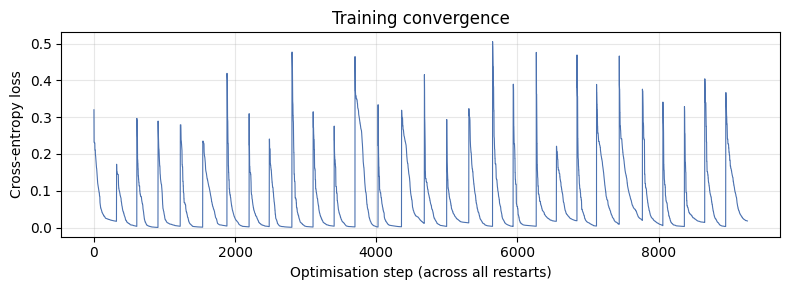

In [20]:
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='#4C72B0', linewidth=0.8)
plt.xlabel('Optimisation step (across all restarts)')
plt.ylabel('Cross-entropy loss')
plt.title('Training convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluating generalisation

The real test. The circuit was trained on 6 of the 9 feature combinations. Can it correctly classify the 3 held-out ones it has never seen?

In [ ]:
print("=== Training set ===")
train_correct = 0
for k in range(len(X_train)):
    prob = predict_prob(X_train[k], best_params)
    pred = 1 if prob > 0.5 else 0
    correct = pred == y_train[k]
    train_correct += correct
    print(f"  {X_train[k]} -> P={prob:.3f}, pred={pred}, true={y_train[k]}")
print(f"Training accuracy: {train_correct}/{len(X_train)}")

print()
print("=== Held-out test (compositional generalisation) ===")
test_correct = 0
for k in range(len(X_test)):
    prob = predict_prob(X_test[k], best_params)
    pred = 1 if prob > 0.5 else 0
    correct = pred == y_test[k]
    test_correct += correct
    print(f"  {X_test[k]} -> P={prob:.3f}, pred={pred}, true={y_test[k]}")
print(f"Test accuracy: {test_correct}/{len(X_test)}")

=== Training set ===
  [0.3 0.5] -> P=0.999, pred=1, true=1 ✓
  [0.3 1.8] -> P=0.000, pred=0, true=0 ✓
  [1.2 0.5] -> P=0.000, pred=0, true=0 ✓
  [1.2 1.8] -> P=1.000, pred=1, true=1 ✓
  [2.1 0.5] -> P=1.000, pred=1, true=1 ✓
  [2.1 1.8] -> P=0.000, pred=0, true=0 ✓
Training accuracy: 6/6

=== Held-out test (compositional generalisation) ===
  [0.3 2.9] -> P=0.777, pred=1, true=1 ✓
  [1.2 2.9] -> P=0.235, pred=0, true=0 ✓
  [2.1 2.9] -> P=0.926, pred=1, true=1 ✓
Test accuracy: 3/3


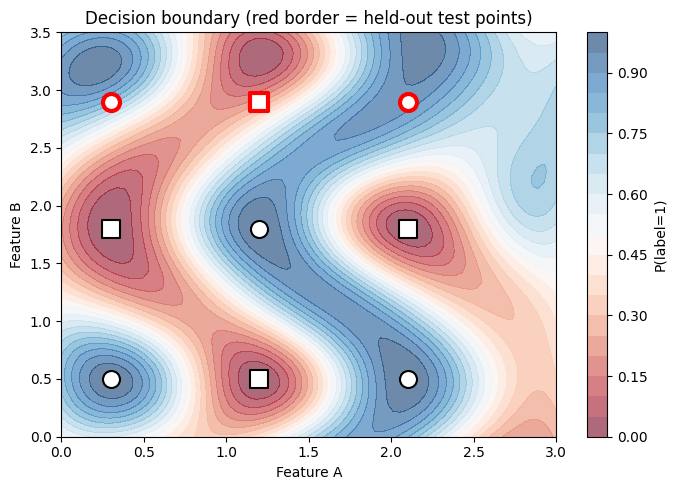

In [22]:
# decision boundary — sweep over the feature space
a_range = np.linspace(0, 3.0, 80)
b_range = np.linspace(0, 3.5, 80)
A_grid, B_grid = np.meshgrid(a_range, b_range)
Z_grid = np.zeros_like(A_grid)

for i in range(len(a_range)):
    for j in range(len(b_range)):
        Z_grid[j, i] = predict_prob([A_grid[j, i], B_grid[j, i]], best_params)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.contourf(A_grid, B_grid, Z_grid, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(im, label='P(label=1)')

for k in range(len(data_points)):
    marker = 'o' if labels[k] == 1 else 's'
    edge = 'red' if test_mask[k] else 'black'
    lw = 3 if test_mask[k] else 1.5
    ax.scatter(data_points[k, 0], data_points[k, 1], marker=marker, c='white',
               s=150, edgecolors=edge, linewidth=lw, zorder=3)

ax.set_xlabel('Feature A')
ax.set_ylabel('Feature B')
ax.set_title('Decision boundary (red border = held-out test points)')
plt.tight_layout()
plt.show()

## Sampling from real measurement counts

The statevector approach gives exact probabilities, but on real hardware we'd get noisy counts. Let me check how the classifier holds up with finite shots.

In [23]:
def predict_from_shots(x, params, n_shots=2048):
    """Predict by measuring the circuit and counting outcomes."""
    qc = build_vqc(x, params)
    qc.measure_all()
    qc_t = transpile(qc, simulator)
    result = simulator.run(qc_t, shots=n_shots).result()
    counts = result.get_counts()
    
    # P(label=1) = fraction of shots where qubit 0 measured |1>
    # measure_all() maps qubit i -> classical bit i
    # Qiskit bitstrings are big-endian: leftmost = highest qubit
    # for 2 qubits: string is 'q1 q0', so qubit 0 is the LAST character
    n_one = sum(c for bitstring, c in counts.items() if bitstring[-1] == '1')
    return n_one / n_shots

print("Exact (statevector) vs Sampled (2048 shots):")
print("-" * 55)
for k in range(len(data_points)):
    p_exact = predict_prob(data_points[k], best_params)
    p_sampled = predict_from_shots(data_points[k], best_params)
    pred_exact = 1 if p_exact > 0.5 else 0
    pred_sampled = 1 if p_sampled > 0.5 else 0
    tag = "TEST" if test_mask[k] else "train"
    print(f"  [{tag}] x={data_points[k]}: exact={p_exact:.3f}({pred_exact}) "
          f"sampled={p_sampled:.3f}({pred_sampled}) true={labels[k]}")

Exact (statevector) vs Sampled (2048 shots):
-------------------------------------------------------
  [train] x=[0.3 0.5]: exact=0.999(1) sampled=0.999(1) true=1
  [train] x=[0.3 1.8]: exact=0.000(0) sampled=0.000(0) true=0
  [TEST] x=[0.3 2.9]: exact=0.777(1) sampled=0.778(1) true=1
  [train] x=[1.2 0.5]: exact=0.000(0) sampled=0.000(0) true=0
  [train] x=[1.2 1.8]: exact=1.000(1) sampled=1.000(1) true=1
  [TEST] x=[1.2 2.9]: exact=0.235(0) sampled=0.240(0) true=0
  [train] x=[2.1 0.5]: exact=1.000(1) sampled=0.999(1) true=1
  [train] x=[2.1 1.8]: exact=0.000(0) sampled=0.000(0) true=0
  [TEST] x=[2.1 2.9]: exact=0.926(1) sampled=0.937(1) true=1


## Does entanglement matter?

One hypothesis in quantum ML: entanglement provides a different inductive bias than classical models. If I remove the CNOT gates, the two qubits can't correlate - the circuit becomes a product of independent single-qubit operations. Does that affect generalisation?

In [26]:
def build_vqc_no_entangle(x, params):
    """Same circuit but without CNOT — no entanglement."""
    qc = QuantumCircuit(n_qubits)
    for l in range(n_layers):
        offset = l * params_per_layer
        qc.ry(params[offset + 0] * x[0] + params[offset + 1], 0)
        qc.ry(params[offset + 2] * x[1] + params[offset + 3], 1)
        qc.ry(params[offset + 4], 0)
        qc.rz(params[offset + 5], 0)
        qc.ry(params[offset + 6], 1)
        qc.rz(params[offset + 7], 1)
        # no cx gate
    final_offset = n_layers * params_per_layer
    qc.ry(params[final_offset], 0)
    qc.ry(params[final_offset + 1], 1)
    return qc

def predict_no_entangle(x, params):
    qc = build_vqc_no_entangle(x, params)
    sv = Statevector.from_instruction(qc)
    return (1 - np.real(sv.expectation_value(Z_op))) / 2

def loss_no_entangle(params, X, y):
    total = 0
    eps = 1e-7
    for k in range(len(X)):
        p = np.clip(predict_no_entangle(X[k], params), eps, 1 - eps)
        total += -(y[k] * np.log(p) + (1 - y[k]) * np.log(1 - p))
    return total / len(X)

best_loss_ne = np.inf
best_params_ne = None
for trial in range(30):
    x0 = np.random.randn(n_params) * 0.3
    for l in range(n_layers):
        offset = l * params_per_layer
        x0[offset] = 1.0 + np.random.randn() * 0.2
        x0[offset + 2] = 1.0 + np.random.randn() * 0.2
    res = minimize(loss_no_entangle, x0, args=(X_train, y_train),
                   method='COBYLA', options={'maxiter': 500, 'rhobeg': 0.5})
    if res.fun < best_loss_ne:
        best_loss_ne = res.fun
        best_params_ne = res.x

print("=== Without entanglement ===")
print(f"Training loss: {best_loss_ne:.6f}")
ne_train = sum(1 for k in range(len(X_train))
               if (1 if predict_no_entangle(X_train[k], best_params_ne) > 0.5 else 0) == y_train[k])
ne_test = 0
for k in range(len(X_test)):
    prob = predict_no_entangle(X_test[k], best_params_ne)
    pred = 1 if prob > 0.5 else 0
    correct = pred == y_test[k]
    ne_test += correct
    print(f"  Test: {X_test[k]} -> P={prob:.3f}, pred={pred}, true={y_test[k]}")
print(f"Train accuracy (no entanglement): {ne_train}/{len(X_train)}")
print(f"Test accuracy (no entanglement): {ne_test}/{len(X_test)}")

print()
ent_train = sum(1 for k in range(len(X_train))
                if (1 if predict_prob(X_train[k], best_params) > 0.5 else 0) == y_train[k])
ent_test = sum(1 for k in range(len(X_test))
               if (1 if predict_prob(X_test[k], best_params) > 0.5 else 0) == y_test[k])
print("=== With entanglement ===")
print(f"Training loss: {best_loss:.6f}")
print(f"Train accuracy (entangled): {ent_train}/{len(X_train)}")
print(f"Test accuracy (entangled): {ent_test}/{len(X_test)}")

=== Without entanglement ===
Training loss: 0.693147
  Test: [0.3 2.9] -> P=0.500, pred=0, true=1
  Test: [1.2 2.9] -> P=0.500, pred=0, true=0
  Test: [2.1 2.9] -> P=0.500, pred=0, true=1
Train accuracy (no entanglement): 3/6
Test accuracy (no entanglement): 1/3

=== With entanglement ===
Training loss: 0.000385
Train accuracy (entangled): 6/6
Test accuracy (entangled): 3/3


## Visualising the quantum states

We can look at the actual quantum state the circuit prepares for different inputs. Since we have 2 qubits, I can compute the reduced state of qubit 0 (the one we measure) and see where it sits on the Bloch sphere.

In [25]:
# compute Bloch vectors for all data points
print("Bloch vectors of qubit 0 for each input:")
print("-" * 65)

bloch_vectors = []
for k in range(len(data_points)):
    qc = build_vqc(data_points[k], best_params)
    sv = Statevector.from_instruction(qc)
    
    # partial trace over qubit 1 to get reduced density matrix of qubit 0
    rho_full = np.array(sv.to_operator())
    # for 2 qubits in Qiskit ordering |q1 q0>:
    # rho_0 = Tr_1(rho) — trace out qubit 1
    rho_0 = np.zeros((2, 2), dtype=complex)
    rho_0[0, 0] = rho_full[0, 0] + rho_full[2, 2]
    rho_0[0, 1] = rho_full[0, 1] + rho_full[2, 3]
    rho_0[1, 0] = rho_full[1, 0] + rho_full[3, 2]
    rho_0[1, 1] = rho_full[1, 1] + rho_full[3, 3]
    
    bx = 2 * np.real(rho_0[0, 1])
    by = -2 * np.imag(rho_0[0, 1])
    bz = np.real(rho_0[0, 0] - rho_0[1, 1])
    purity = np.sqrt(bx**2 + by**2 + bz**2)
    bloch_vectors.append([bx, by, bz])
    
    prob = predict_prob(data_points[k], best_params)
    tag = "TEST" if test_mask[k] else "train"
    print(f"  [{tag}] label={labels[k]} P(1)={prob:.3f} "
          f"Bloch=({bx:+.2f},{by:+.2f},{bz:+.2f}) |r|={purity:.3f}")

# |r| < 1 means the qubit is entangled with qubit 1
# this tells us the circuit is genuinely using quantum correlations

Bloch vectors of qubit 0 for each input:
-----------------------------------------------------------------
  [train] label=1 P(1)=0.999 Bloch=(-0.02,+0.03,-1.00) |r|=0.999
  [train] label=0 P(1)=0.000 Bloch=(-0.03,-0.02,+1.00) |r|=1.000
  [TEST] label=1 P(1)=0.777 Bloch=(+0.59,-0.43,-0.55) |r|=0.915
  [train] label=0 P(1)=0.000 Bloch=(+0.00,-0.01,+1.00) |r|=0.999
  [train] label=1 P(1)=1.000 Bloch=(+0.02,-0.01,-1.00) |r|=1.000
  [TEST] label=0 P(1)=0.235 Bloch=(-0.24,+0.59,+0.53) |r|=0.828
  [train] label=1 P(1)=1.000 Bloch=(-0.02,+0.01,-1.00) |r|=1.000
  [train] label=0 P(1)=0.000 Bloch=(+0.01,+0.02,+1.00) |r|=1.000
  [TEST] label=1 P(1)=0.926 Bloch=(+0.40,+0.27,-0.85) |r|=0.980
